### since crop is a categorical variable  its a classification problem 
### since we have labelled data its a supervised learning problem [input features and corresponding crop]

# Importing the libraries , datasets and Splitting

In [4]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

In [5]:
dataset = pd.read_csv('datasets/Crop_recommendation.csv')
X = dataset.iloc[:,:-1].values
y = dataset.iloc[:, -1].values
print(dataset.head())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

### check for missing data 

In [7]:
print(dataset.isnull().sum()) # no missing values 

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


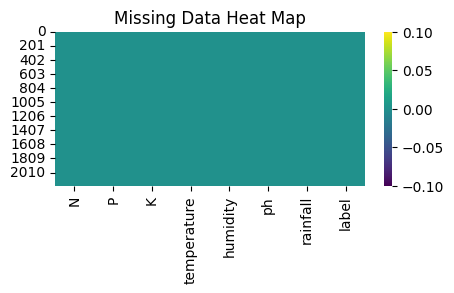

In [8]:
plt.figure(figsize=(5,2))
sns.heatmap(dataset.isnull(),  cmap="viridis")
plt.title("Missing Data Heat Map")
plt.show()

# FEATURE SCALING
**Feature scaling is required before creating training data and feeding it to the model.**

two of our features (temperature and ph) are gaussian distributed, therefore scaling them between 0 and 1 with MinMaxScaler.

In [9]:

# Feature scaling
from sklearn.preprocessing import StandardScaler , MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model Selection

In [10]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators=100, max_depth=5,criterion='entropy', random_state=0)
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=5, random_state=0)

In [11]:
y_pred = classifier.predict(X_test)

In [12]:
from sklearn.metrics import confusion_matrix , accuracy_score
cm = confusion_matrix(y_test ,y_pred)
# print(cm)
accuracy_score(y_test, y_pred)

0.9945454545454545

# Saving the model

In [14]:
import joblib
joblib.dump(classifier , 'Modelss/RandomForestCropModel.pkl')

['Modelss/RandomForestCropModel.pkl']